This python code is for an application of the NEMO (NEighborhood based Multi-Omics clustering) multi-omics analysis of partially measured data, implemented by Wenyan Luo. 

Reference:
Nimrod Rappoport, Ron Shamir, NEMO: cancer subtyping by integration of partial multi-omic data, Bioinformatics, Volume 35, Issue 18, September 2019, Pages 3348–3356, https://doi.org/10.1093/bioinformatics/btz058

In [ ]:
# Follow the EDA by Almed Tohamy
import pandas as pd
# Load three files into pandas
rppaFilePath = '../data/TCGA2021/data_rppa.txt'
rnaFilePath = '../data/TCGA2021/data_mrna_seq_v2_rsem.txt'
clinFilePath = '../data/TCGA2021/data_clinical_patient.txt'

rppa_raw = pd.read_csv(rppaFilePath, sep='\t', index_col = 0) 
print("Shape of RPPA:", rppa_raw.shape)

rna_raw = pd.read_csv(rnaFilePath, sep='\t',low_memory=False)
print("Shape of RNA-Seq:", rna_raw.shape)

clin_raw = pd.read_csv(clinFilePath, sep='\t', comment="#")
print('Shape of clinical_patient is:', clin_raw.shape)

In [ ]:
rppa_raw.head()

In [ ]:
rna_raw.head()

In [ ]:
clin_raw.head()

In [ ]:
# Clean and standardize IDs
def tcga_base_id(x):
    # keep first three parts: TCGA-XX-YYYY
    return '-'.join(x.split('-')[:3])

# Clean RPPA columns
rppa = rppa_raw.copy()
rppa.columns = [tcga_base_id(c) for c in rppa.columns]

# Clean RNA columns (skip the first two metadata columns)
rna = rna_raw.drop(columns=['Hugo_Symbol', 'Entrez_Gene_Id']).copy()
rna.columns = [tcga_base_id(c) for c in rna.columns]

# Clean clinical IDs
clin = clin_raw.copy()
clin['PATIENT_ID'] = clin['PATIENT_ID'].apply(tcga_base_id)


In [ ]:
rppa.head()

In [ ]:
# Remove duplicated patient IDs and take transpose for rppa and rna
rppa = rppa.loc[:, ~rppa.columns.duplicated()]
rppa = rppa.T

rna  = rna.loc[:,  ~rna.columns.duplicated()]
rna  = rna.T

clin = clin.drop_duplicates(subset='PATIENT_ID', keep='first')


In [ ]:
# rppa.head()
# rna.head()
clin.head()
print(clin.columns.tolist())

In [ ]:
# Convert everything to numeric
rppa = rppa.apply(pd.to_numeric, errors='coerce')
rna  = rna.apply(pd.to_numeric, errors='coerce')

# Drop features (columns) with >20% missing values
rppa = rppa.dropna(axis=1, thresh=int(0.8 * len(rppa)))
rna  = rna.dropna(axis=1, thresh=int(0.8 * len(rna)))

# Fill remaining NaNs with feature means
rppa = rppa.fillna(rppa.mean())
rna  = rna.fillna(rna.mean())


In [ ]:
# sanity check for shape
print("The shape of rna after cleaning: ", rna.shape)
print("The shape of rppa after cleaning: ", rppa.shape)
print("The shape of clin after cleaning: ", clin.shape)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# RPPA normalization
rppa_z = pd.DataFrame(
    scaler.fit_transform(rppa),
    index = rppa.index,
    columns = rppa.columns
)

rna_z = pd.DataFrame(
    scaler.fit_transform(rna),
    index = rna.index,
    columns = rna.columns
)



In [ ]:
print("After z-score normalization:")
print("RPPA_z shape:", rppa_z.shape)
print("RNA_z  shape:", rna_z.shape)
# rppa_z.mean().mean(), rppa_z.std().mean()


In [ ]:
# collect the sample IDs (row)
samples_rna  = set(rna_z.index)
samples_rppa = set(rppa_z.index)
samples_clin = set(clin['PATIENT_ID'])

# Compute intersections and unique samples
common_rna_rppa = samples_rna & samples_rppa
common_all      = samples_rna & samples_rppa & samples_clin

print(f"RNA-only samples:  {len(samples_rna) - len(common_rna_rppa)}")
print(f"RPPA-only samples: {len(samples_rppa) - len(common_rna_rppa)}")
print(f"Overlap RNA ∩ RPPA: {len(common_rna_rppa)}")
print(f"Overlap RNA ∩ RPPA ∩ Clinical: {len(common_all)}")

print(f"The total number of samples: {len(samples_rna) + len(samples_rppa) - len(common_rna_rppa)}")

| Column                      | Meaning                                                     |
| --------------------------- | ----------------------------------------------------------- |
| `OS_STATUS`                 | survival event indicator (often `"DECEASED"` or `"LIVING"`) |
| `OS_MONTHS`                 | overall survival time in months                             |
| `DSS_STATUS` / `DSS_MONTHS` | disease-specific survival (optional alternative)            |
| `PFS_STATUS` / `PFS_MONTHS` | progression-free survival (optional alternative)            |

For clin we focus on the above features. 

In [ ]:
union_samples = sorted(samples_rna | samples_rppa)

rna_union  = rna_z.loc[rna_z.index.isin(union_samples)]
rppa_union = rppa_z.loc[rppa_z.index.isin(union_samples)]

print("Union sizes:")
print("RNA_union :",  rna_union.shape)
print("RPPA_union:", rppa_union.shape)

# Select columns for survival analysis
clin_surv = clin[ ["PATIENT_ID", "OS_STATUS", "OS_MONTHS"] ].copy()
# convert OS_STATUS to a binary variables: 1 = death, 0 = alive/censored
clin_surv["OS_EVENT"] = clin_surv["OS_STATUS"].apply(
    lambda x: 1 if str(x).upper().startswith("1") else 0
)

# keep only patients in union of omics
clin_surv_union = clin_surv[ clin_surv["PATIENT_ID"].isin(union_samples) ]

print("Cleaned survival table:")
print(clin_surv_union.head())
print("Shape:", clin_surv_union.shape)

In [ ]:
import pandas as pd
import numpy as np

# --- 9.1 Define key sample sets ---
rna_ids   = set(rna_union.index)
rppa_ids  = set(rppa_union.index)
surv_ids  = set(clin_surv_union['PATIENT_ID'])

union_ids = sorted(rna_ids | rppa_ids)                     # all patients with ≥1 omic
eval_ids  = sorted((rna_ids | rppa_ids) & surv_ids)        # patients we can use for survival evaluation

# --- 9.2 Build a unified index DataFrame ---
sample_df = pd.DataFrame(index=union_ids)
sample_df.index.name = "PATIENT_ID"

sample_df["has_RNA"]   = sample_df.index.isin(rna_ids).astype(int)
sample_df["has_RPPA"]  = sample_df.index.isin(rppa_ids).astype(int)
sample_df["in_survival"]= sample_df.index.isin(surv_ids).astype(int)

# Attach survival columns (align on PATIENT_ID; may produce NaNs for non-survival rows)
surv_small = clin_surv_union.set_index("PATIENT_ID")[["OS_MONTHS","OS_EVENT"]]
sample_df = sample_df.join(surv_small, how="left")

# Optional: a convenience mask for survival-ready rows
sample_df["survival_ready"] = sample_df["in_survival"].eq(1) & sample_df["OS_MONTHS"].notna()

# --- 9.3 Quick sanity report ---
print("Unified sample table (head):")
display(sample_df.head())

print("\nCounts:")
print("Total (union) patients         :", len(sample_df))
print("Patients with RNA              :", int(sample_df['has_RNA'].sum()))
print("Patients with RPPA             :", int(sample_df['has_RPPA'].sum()))
print("Patients with survival columns :", int(sample_df['in_survival'].sum()))
print("Survival-ready (non-null time) :", int(sample_df['survival_ready'].sum()))


First, we create a similarity matrix within an omic, using kNN

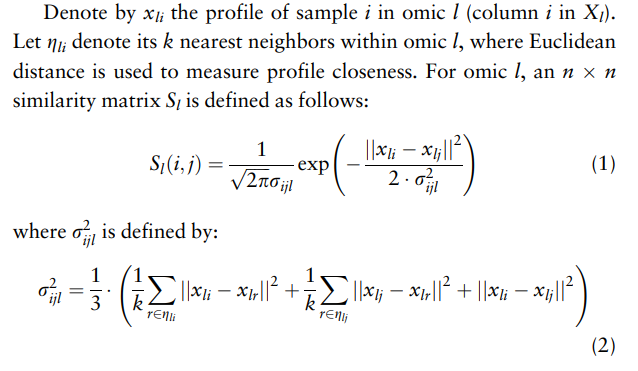

(Screenshot from the reference paper, page 3349)

In [ ]:
from scipy.spatial.distance import cdist
def compute_similarity(X, k = 10):
    # to use cdist, we need numpy array as dtype. To reduce memory, we use np.asarray
    X = np.asarray(X, dtype = float)
    n = X.shape[0] # number of samples within the omic
    k = max(1, min(k, n-1))    # ensure valid k

    # compute Euclidean distance matrix
    D2 = cdist(X, X, metric = "sqeuclidean")
    D2_sorted = np.sort(D2, axis = 1)
    nn_idx = np.argsort(D2, axis=1)[:, 1:k+1]   # shape (n, k)
    knn_means = D2_sorted[:, 1:k+1].mean(axis = 1) # compute the k neighbor mean
    # compute sigma_{ijl}
    S = np.zeros_like(D2) # create a similarity matrix with the same dimension as D2
    for ii in range(n):
        for jj in range(n):
            sigma_sq = knn_means[ii] + knn_means[jj] + D2[ii,jj] 
            sigma_sq = sigma_sq / 3
            S[ii,jj] = np.exp( - D2[ii,jj]/(2 * sigma_sq + 1e-12) )  / ( np.sqrt(2 * np.pi * sigma_sq)  )

    return S,  nn_idx

k = 15
S_rna, knn_idx_rna  = compute_similarity(rna_union, k )
S_rppa, knn_idx_rppa = compute_similarity(rppa_union, k )

print("Similarity shapes:")
print("RNA :", S_rna.shape)
print("RPPA:", S_rppa.shape)

In [ ]:
print(knn_idx_rna.shape)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create one figure with 2 subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))# RNA similarity heatmap

# RNA similarity heatmap
sns.heatmap(S_rna, ax = axes[0], cmap="viridis", square=True, cbar_kws={"label": "Similarity"})
axes[0].set_title("RNA Similarity (k=10)")
axes[0].set_xlabel("Samples")
axes[0].set_ylabel("Samples")


# RPPA similarity heatmap
sns.heatmap(S_rppa, ax = axes[1], cmap="viridis", square=True, cbar_kws={"label": "Similarity"})
axes[1].set_title("RPPA Similarity (k=10)")
axes[1].set_xlabel("Samples")
axes[1].set_ylabel("Samples")

# adjust layout
plt.tight_layout()
plt.show()


Next we compute the relative similarity matrix RS_l

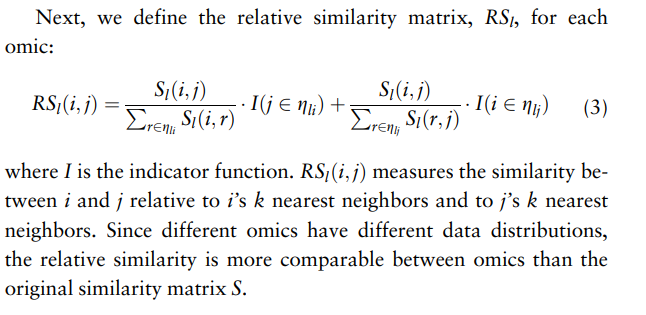

(Screenshot from the reference paper, page 3349)

In [ ]:
def compute_relative_similarity(S, knn_idx, k=10):
    S = np.asarray(S, dtype = float)
    n = S.shape[0]
    k = max(1, min(k, n-1))

    RS = np.zeros_like(S)
    for ii in range(n):
        for jj in range(n):
            check_i_nn = int(np.isin(jj, knn_idx[ii,:]))
            check_j_nn = int(np.isin(ii, knn_idx[jj,:]))
            RS[ii,jj]   = check_i_nn * S[ii,jj]/np.sum(S[ii,knn_idx[ii]])
            RS[ii,jj]  += check_j_nn * S[ii,jj]/np.sum(S[knn_idx[jj],jj])
    
    return RS

    

# --- Build RS for each omic on its own sample set ---
RS_rna  = compute_relative_similarity(S_rna, knn_idx_rna, k)
RS_rppa = compute_relative_similarity(S_rppa, knn_idx_rppa, k)


In [ ]:
print(f'RS_rna has shape {RS_rna.shape}')
print(f'RS_rppa has shape {RS_rppa.shape}')

In [ ]:
# Create one figure with 2 subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))# RNA similarity heatmap

# RNA similarity heatmap
sns.heatmap(RS_rna, ax = axes[0], cmap="viridis", square=True, cbar_kws={"label": "Similarity"})
axes[0].set_title("RNA Similarity (k=10)")
axes[0].set_xlabel("Samples")
axes[0].set_ylabel("Samples")


# RPPA similarity heatmap
sns.heatmap(RS_rppa, ax = axes[1], cmap="viridis", square=True, cbar_kws={"label": "Similarity"})
axes[1].set_title("RPPA Similarity (k=10)")
axes[1].set_xlabel("Samples")
axes[1].set_ylabel("Samples")

# adjust layout
plt.tight_layout()
plt.show()


Now compute the ARS ( the average relative similarity matrix ): 

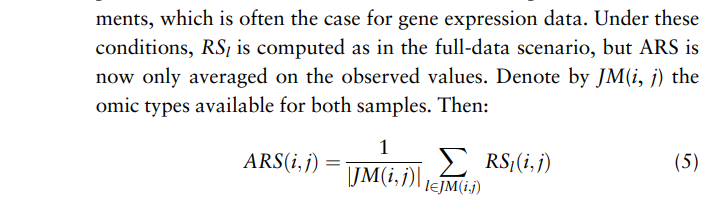

(Screenshot from the reference paper, page 3350)

In [ ]:
def compute_ARS(rs_list, id_list):
    union_ids = sorted(set().union(*id_list))
    nU        = len(union_ids)
    pos_union = {sid:i  for i, sid in enumerate(union_ids)}
    ARS_sum = np.zeros((nU, nU), dtype=float)
    ARS_cnt = np.zeros((nU, nU), dtype=float)

    # --- accumulate RS_l where both samples exist ---
    for RS, ids in zip(rs_list, id_list):
        idx = np.array([pos_union[s] for s in ids])
        ARS_sum[np.ix_(idx, idx)] += RS
        ARS_cnt[np.ix_(idx, idx)] += 1.0
    # --- average only over observed omics ---
    ARS = np.divide(ARS_sum, ARS_cnt, out=np.zeros_like(ARS_sum), where=ARS_cnt>0)
    
    return ARS, union_ids

ARS, union_ids = compute_ARS(
    rs_list=[RS_rna, RS_rppa],
    id_list=[list(rna_union.index), list(rppa_union.index)]
)

print("ARS shape:", ARS.shape)


In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))

sns.heatmap(ARS, ax = ax, cmap="viridis", square=True, cbar_kws={"label": "Similarity"})
ax.set_title("Average Relative Similarity (ARS)")
ax.set_xlabel("Samples")
ax.set_ylabel("Samples")

plt.tight_layout()
plt.show()

After obtaining the ARS, we can carry out clustering to the union data. We consider two types of clustering methods: Spectral clustering and Diffusion map. The log rank test suggests K = 5 to 6 clusters is appropriate to do inference on ARS. 

In [ ]:
from scipy.linalg import eigh

# --- Compute normalized Laplacian ---
# Degree matrix
d = ARS.sum(axis=1)
D_inv_sqrt = np.diag(1.0 / np.sqrt(d + 1e-12))
L = np.eye(len(ARS)) - D_inv_sqrt @ ARS @ D_inv_sqrt

# --- Compute smallest eigenvalues (ascending) ---
# eigh gives sorted ascending eigenvalues for symmetric matrices
eigvals, eigvecs = eigh(L)
print("First 10 eigenvalues:\n", np.round(eigvals[:10], 4))

# --- Plot eigengap ---
plt.figure(figsize=(6,4))
plt.plot(range(1, 11), eigvals[:10], "o-", lw=2)
plt.title("Eigengap Analysis (Normalized Laplacian)")
plt.xlabel("Eigenvalue Index")
plt.ylabel("Eigenvalue λ")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

gaps = np.diff(eigvals[:10])
K_opt = np.argmax(gaps) + 1  # +1 because diff reduces length by 1
print(f"Suggested number of clusters (K): {K_opt}")


In [ ]:
from sklearn.cluster import SpectralClustering

# Choose number of clusters K (you can tune via eigengap or domain knowledge)
K = 6

# Spectral clustering on ARS
model = SpectralClustering(
    n_clusters=K,
    affinity='precomputed',
    random_state=0
)
clusters = model.fit_predict(ARS)

# Attach cluster labels back to your sample index
import pandas as pd
cluster_df = pd.DataFrame({
    "PATIENT_ID": union_ids,
    "Cluster": clusters
})
print(cluster_df.head())


In [ ]:
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

# Merge cluster assignments with survival table
df = pd.merge(cluster_df, clin_surv_union, on="PATIENT_ID", how="inner")
# Drop patients with missing survival info
df = df.dropna(subset=["OS_MONTHS", "OS_EVENT"]).copy()
df["OS_EVENT"] = df["OS_EVENT"].astype(int)

# Plot KM curves per cluster
kmf = KaplanMeierFitter()
plt.figure(figsize=(6,5))

for c in sorted(df["Cluster"].unique()):
    subset = df[df["Cluster"] == c]
    kmf.fit(subset["OS_MONTHS"], event_observed=subset["OS_EVENT"], label=f"Cluster {c}")
    kmf.plot(ci_show=False)

plt.title("Kaplan–Meier Survival by Cluster")
plt.xlabel("Time (months)")
plt.ylabel("Survival probability")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()




In [ ]:
from lifelines.statistics import multivariate_logrank_test

# Multivariate log-rank test across all clusters
results = multivariate_logrank_test(
    event_durations=df["OS_MONTHS"],
    groups=df["Cluster"],
    event_observed=df["OS_EVENT"]
)
print("Global log-rank test p-value:", results.p_value)


In [ ]:
from scipy.sparse.linalg import eigs

def diffusion_map_from_similarity(S, n_components=3, alpha=1.0):
    """
    Compute diffusion map embedding from a similarity matrix S (e.g. ARS).

    Parameters
    ----------
    S : array-like (n_samples, n_samples)
        Similarity / affinity matrix (symmetric, nonnegative)
    n_components : int
        Number of diffusion coordinates to return.
    alpha : float
        Normalization parameter (1 = symmetric normalization).

    Returns
    -------
    embedding : ndarray (n_samples, n_components)
    eigenvalues : ndarray (n_components,)
    """
    # --- 1. Normalize to Markov transition matrix ---
    S = np.asarray(S, dtype=float)
    n = S.shape[0]

    # Row degree (sum of similarities)
    d = S.sum(axis=1)
    D_alpha = np.power(d, -alpha)
    D_alpha[np.isinf(D_alpha)] = 0
    K = (D_alpha[:, None] * S) * D_alpha[None, :]

    # Normalize rows to sum to 1 (Markov transition)
    P = K / (K.sum(axis=1, keepdims=True) + 1e-12)

    # --- 2. Compute top eigenvectors of P ---
    vals, vecs = eigs(P, k=n_components + 1, which='LR')  # largest real parts
    vals = np.real(vals)
    vecs = np.real(vecs)

    # Sort by eigenvalue magnitude descending
    idx = np.argsort(-vals)
    vals, vecs = vals[idx], vecs[:, idx]

    # Skip the first trivial eigenvector (constant)
    embedding = vecs[:, 1:n_components+1] * vals[1:n_components+1]

    return embedding, vals[1:n_components+1]

# --- Compute diffusion embedding ---
Y, eigvals = diffusion_map_from_similarity(ARS, n_components=3)

print("Eigenvalues:", np.round(eigvals, 4))
print("Embedding shape:", Y.shape)

# --- Visualization (3D scatter) ---
fig = plt.figure(figsize=(7,6))
ax = fig.add_subplot(111, projection="3d")
sc = ax.scatter(Y[:,0], Y[:,1], Y[:,2], c=clusters, cmap="tab10", s=40, alpha=0.8)
ax.set_title("Diffusion Map Embedding of ARS")
ax.set_xlabel("Diffusion 1")
ax.set_ylabel("Diffusion 2")    
ax.set_zlabel("Diffusion 3")
plt.colorbar(sc, label="Cluster")
plt.tight_layout()
plt.show()
